# Scheduling simulator — exploration

Thin notebook layered on top of `shared/comparison.py`, `shared/reporter.py`, and `shared/plots.py`.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from models.process.workload import Workload
from schedulers.round_robin import RoundRobin
from shared.comparison import COMPARISON_METRICS, pick_winners, run_all
from shared.metrics import compute_metrics
from shared.parser import parse_input
from shared.plots import plot_gantt, plot_metric_bars
from shared.reporter import print_comparison
from shared.simulator import Simulator

workload = parse_input("inputs/workload.txt")
workload

In [2]:
pairs = run_all(workload)
results = [r for r, _ in pairs]
reports = [m for _, m in pairs]
len(results), len(reports)

(5, 5)

In [3]:
print_comparison(reports, pick_winners(reports))

Comparison
algorithm         avg_turnaround  avg_waiting  avg_response  cpu_utilization
----------------  --------------  -----------  ------------  ---------------
FCFS              12.0000         6.0000       4.5000        1.0000         
SJF               11.0000         5.0000       3.7500        1.0000         
SJF (preemptive)  11.0000         5.0000       1.7500        1.0000         
Priority          11.5000         5.5000       5.0000        0.9048         
Round Robin       12.2500         6.2500       1.7500        0.9500         

Winner per metric
  avg_turnaround: SJF
  avg_waiting: SJF
  avg_response: SJF (preemptive)
  cpu_utilization: FCFS


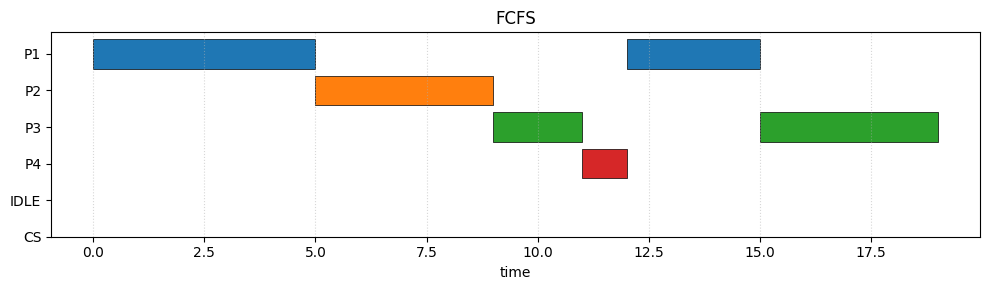

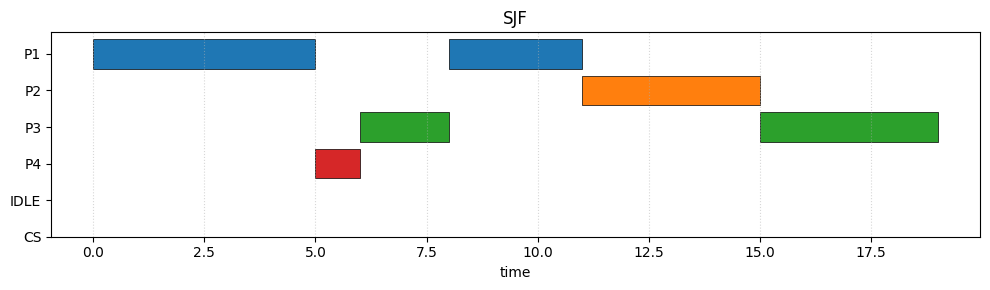

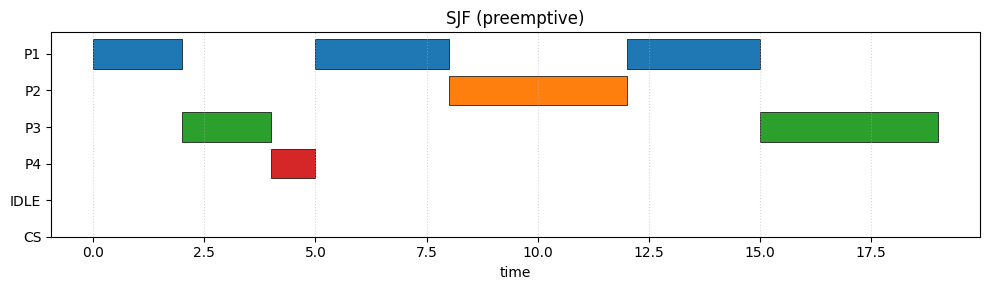

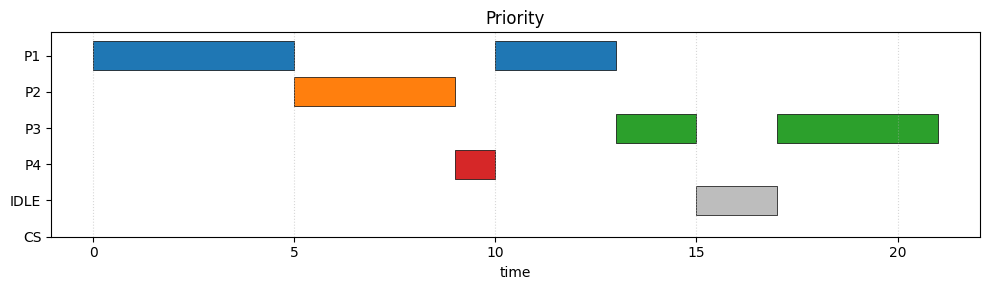

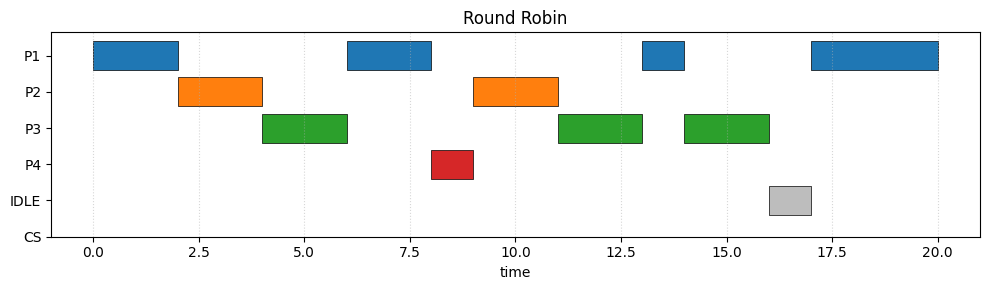

In [4]:
for result in results:
    fig, ax = plt.subplots(figsize=(10, 3))
    plot_gantt(result, ax=ax)
    fig.tight_layout()
    plt.show()

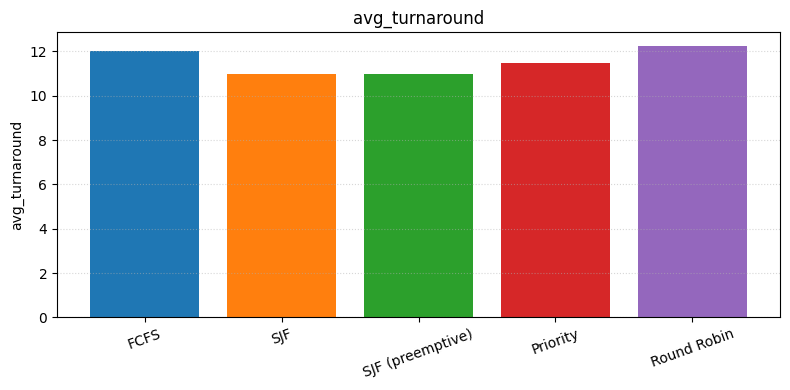

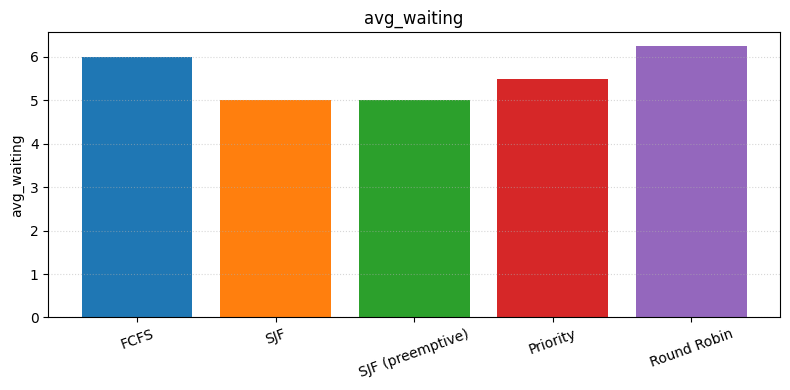

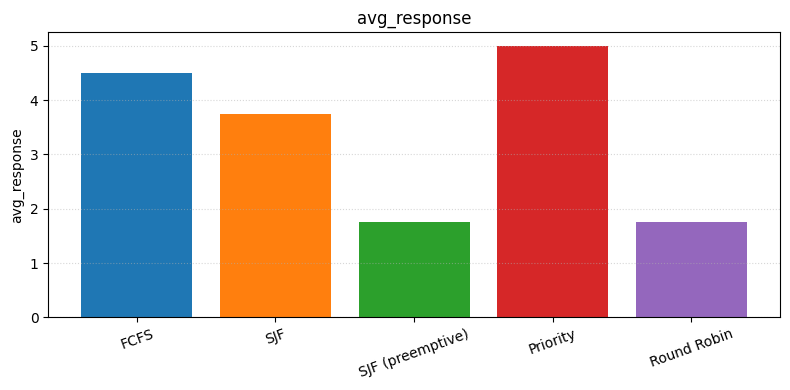

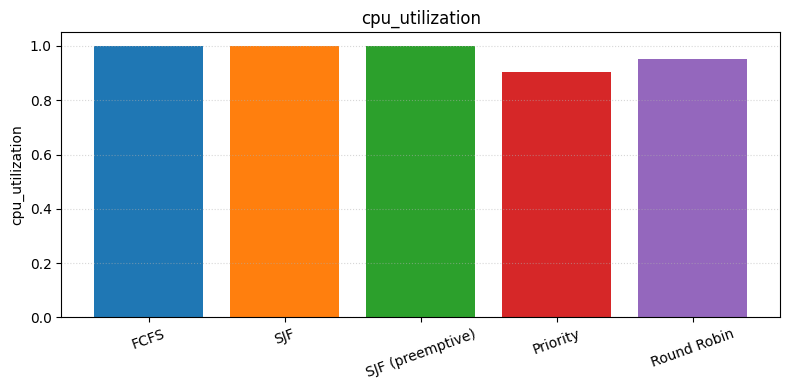

In [5]:
for metric in COMPARISON_METRICS:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_metric_bars(reports, metric, ax=ax)
    fig.tight_layout()
    plt.show()

## Context-switch cost exploration

Re-runs Round Robin with `context_switch_cost in {0, 1, 2}` and plots avg turnaround and CPU utilization.

In [ ]:
cs_costs = (0, 1, 2)
rr_reports = []
for cs in cs_costs:
    print(cs)
    variant = Workload(
        processes=workload.processes,
        quantum=workload.quantum,
        context_switch_cost=cs,
    )
    rr_result = Simulator(variant, RoundRobin(variant.quantum)).run()
    rr_reports.append((cs, compute_metrics(rr_result)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(
    [cs for cs, _ in rr_reports],
    [m.avg_turnaround for _, m in rr_reports],
    marker="o",
)
axes[0].set_title("avg_turnaround vs cs_cost")
axes[0].set_xlabel("cs_cost")
axes[0].set_ylabel("avg_turnaround")
axes[0].grid(linestyle=":", alpha=0.5)

axes[1].plot(
    [cs for cs, _ in rr_reports],
    [m.cpu_utilization for _, m in rr_reports],
    marker="o",
    color="tab:orange",
)
axes[1].set_title("cpu_utilization vs cs_cost")
axes[1].set_xlabel("cs_cost")
axes[1].set_ylabel("cpu_utilization")
axes[1].grid(linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()
print("finished")

In [7]:
winners = pick_winners(reports)
for metric, algo in winners.items():
    print(f"{metric}: {algo}")

avg_turnaround: SJF
avg_waiting: SJF
avg_response: SJF (preemptive)
cpu_utilization: FCFS
